# 04 - Trayectoria, indicadores y estados

## 1. Dependencias

In [1]:
#Instalar dependencias
%pip install pandas numpy scikit-learn matplotlib joblib

Note: you may need to restart the kernel to use updated packages.


## 2. Configuración

In [2]:
#Librerías
import platform
import sys
from pathlib import Path
import joblib
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from IPython.display import display
from matplotlib.ticker import FuncFormatter
from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score
from sklearn.metrics import balanced_accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import f1_score
from sklearn.metrics import log_loss
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [3]:
#Configuración
SEMILLA = 20260727
UMBRAL_CONFIANZA = 0.50
UMBRAL_CONFIANZA_ALTA = 0.75
MIN_DIAS_TRAYECTORIA = 30
MIN_TRANSACCIONES_TRAYECTORIA = 10
MIN_PCT_CLASIFICABLE = 0.70
PERFIL_GRAFICA = 'PERF_0042'
VERSION_MODELO = 'fincoah_estados_trayectoria_mvp_v1'

ruta_perfiles = Path('../Datasets/perfil_integral_usuario.csv')
ruta_transacciones = Path('../Datasets/transacciones_contextualizadas.csv')
ruta_trayectorias = Path('../Datasets/trayectorias_financieras.csv')
ruta_recurrencias = Path('../Resultados/03_recurrencias_observadas.csv')
ruta_tendencias = Path('../Resultados/03_tendencias_observadas.csv')
ruta_eventos = Path('../Resultados/03_eventos_inusuales.csv')
ruta_modelo = Path('../Modelos/04_estados_trayectoria.joblib')
ruta_resultados = Path('../Resultados')
ruta_graficas = ruta_resultados / 'Graficas'

versiones = pd.DataFrame([
    {'componente': 'python', 'version': sys.version.split()[0]},
    {'componente': 'pandas', 'version': pd.__version__},
    {'componente': 'numpy', 'version': np.__version__},
    {'componente': 'scikit-learn', 'version': sklearn.__version__},
    {'componente': 'matplotlib', 'version': matplotlib.__version__},
    {'componente': 'sistema', 'version': platform.platform()},
])

display(versiones)

,componente,version
0,python,3.14.3
1,pandas,3.0.3
2,numpy,2.5.1
3,scikit-learn,1.9.0
4,matplotlib,3.11.1
5,sistema,macOS-26.5.2-arm64-arm-64bit-Mach-O


## 3. Carga de datos

In [4]:
#Cargar datos
perfiles = pd.read_csv(ruta_perfiles, low_memory=False)
transacciones = pd.read_csv(ruta_transacciones, low_memory=False)
trayectorias = pd.read_csv(ruta_trayectorias, low_memory=False)
recurrencias = pd.read_csv(ruta_recurrencias, low_memory=False)
tendencias_temporales = pd.read_csv(ruta_tendencias, low_memory=False)
eventos_inusuales = pd.read_csv(ruta_eventos, low_memory=False)

for columna in ['fecha_corte', 'periodo_desde', 'periodo_hasta']:
    trayectorias[columna] = pd.to_datetime(trayectorias[columna], errors='coerce')

transacciones['fecha'] = pd.to_datetime(transacciones['fecha'], errors='coerce')

resumen_fuentes = pd.DataFrame([
    {'fuente': 'perfiles', 'filas': len(perfiles), 'perfiles': perfiles['perfil_id'].nunique()},
    {'fuente': 'transacciones', 'filas': len(transacciones), 'perfiles': transacciones['perfil_id'].nunique()},
    {'fuente': 'trayectorias', 'filas': len(trayectorias), 'perfiles': trayectorias['perfil_id'].nunique()},
    {'fuente': 'recurrencias', 'filas': len(recurrencias), 'perfiles': recurrencias['perfil_id'].nunique()},
    {'fuente': 'tendencias', 'filas': len(tendencias_temporales), 'perfiles': tendencias_temporales['perfil_id'].nunique()},
    {'fuente': 'eventos inusuales', 'filas': len(eventos_inusuales), 'perfiles': eventos_inusuales['perfil_id'].nunique()},
])

display(resumen_fuentes)
display(trayectorias.head(5))

,fuente,filas,perfiles
0,perfiles,200,200
1,transacciones,19077,200
2,trayectorias,600,200
3,recurrencias,9557,200
4,tendencias,400,200
5,eventos inusuales,734,188


,ventana_id,perfil_id,estado_alcance_mvp,fecha_corte,periodo_desde,periodo_hasta,tipo_ventana,dias_observados,transacciones_observadas,porcentaje_transacciones_clasificables,...,factores_atencion,informacion_faltante,explicacion_periodo,fuente_etiqueta,particion,historia_financiera_controlada,es_sintetico,version_metodologia,version_esquema,huella_registro
0,VEN_0001_1,PERF_0001,dentro_del_mvp,2026-04-30,2026-04-01,2026-04-30,acumulada_30_dias,30,32,0.9375,...,sin_factor_de_atencion_dominante,ninguna_relevante_para_el_periodo,"El periodo conserva balance favorable, liquide...",historia_controlada_y_metricas_observadas,train,acumulacion_estable,si,roadmap_14_mvp_cerrado_v1.1,fincoah_mvp_co_v1.1,0572cc37dee90daa35af4b59afb31041742ad8b4198044...
1,VEN_0001_2,PERF_0001,dentro_del_mvp,2026-05-31,2026-04-01,2026-05-31,acumulada_61_dias,61,64,0.9531,...,sin_factor_de_atencion_dominante,destino_del_efectivo_fuera_del_banco,"El periodo conserva balance favorable, liquide...",historia_controlada_y_metricas_observadas,train,acumulacion_estable,si,roadmap_14_mvp_cerrado_v1.1,fincoah_mvp_co_v1.1,9f8843abe4e255a42fc224ceccf3673de78e7b30174cfd...
2,VEN_0001_3,PERF_0001,dentro_del_mvp,2026-06-30,2026-04-01,2026-06-30,acumulada_91_dias,91,96,0.9479,...,sin_factor_de_atencion_dominante,destino_del_efectivo_fuera_del_banco,"El periodo conserva balance favorable, liquide...",historia_controlada_y_metricas_observadas,train,acumulacion_estable,si,roadmap_14_mvp_cerrado_v1.1,fincoah_mvp_co_v1.1,3d8fd89a6ccd1341d054a21356346f102a050e36ad7f26...
3,VEN_0002_1,PERF_0002,dentro_del_mvp,2026-04-30,2026-04-01,2026-04-30,acumulada_30_dias,30,32,0.9688,...,sin_factor_de_atencion_dominante,destino_del_efectivo_fuera_del_banco,El periodo permanece cerca del equilibrio y ma...,historia_controlada_y_metricas_observadas,train,equilibrio_sostenible,si,roadmap_14_mvp_cerrado_v1.1,fincoah_mvp_co_v1.1,9a8bb974a94ae79bfa0905aade09b8fd9047aab3ebb2c6...
4,VEN_0002_2,PERF_0002,dentro_del_mvp,2026-05-31,2026-04-01,2026-05-31,acumulada_61_dias,61,64,0.9844,...,sin_factor_de_atencion_dominante,destino_del_efectivo_fuera_del_banco,El periodo permanece cerca del equilibrio y ma...,historia_controlada_y_metricas_observadas,train,equilibrio_sostenible,si,roadmap_14_mvp_cerrado_v1.1,fincoah_mvp_co_v1.1,2dd8b1bf64488e1a6884c1070ce444f376e4ee7dbfbe47...


## 4. Contrato, cobertura y separación de perfiles

In [5]:
#Validar contrato
indicadores_crudos = [
    'actividad_A',
    'balance_operativo_B',
    'presion_deficit_Q',
    'caida_maxima_M',
    'tiempo_sin_recuperar_U_dias',
    'recuperacion_R',
    'curvatura_K',
    'variabilidad_ingresos_V',
    'cobertura_esencial_L_meses',
    'dependencia_externa_X',
    'crecimiento_deuda_J',
]

columnas_requeridas = [
    'ventana_id',
    'perfil_id',
    'fecha_corte',
    'periodo_desde',
    'periodo_hasta',
    'dias_observados',
    'transacciones_observadas',
    'porcentaje_transacciones_clasificables',
    'estado_trayectoria',
    'particion',
    *indicadores_crudos,
]

columnas_faltantes = sorted(set(columnas_requeridas) - set(trayectorias.columns))
perfiles_por_particion = trayectorias.groupby('perfil_id')['particion'].nunique()
errores_contrato = pd.DataFrame([
    {'control': 'columnas requeridas', 'errores': len(columnas_faltantes)},
    {'control': 'fechas válidas', 'errores': int(trayectorias[['fecha_corte', 'periodo_desde', 'periodo_hasta']].isna().any(axis=1).sum())},
    {'control': 'indicadores disponibles', 'errores': int(trayectorias[indicadores_crudos].isna().any(axis=1).sum())},
    {'control': 'partición válida', 'errores': int((~trayectorias['particion'].isin(['train', 'validation', 'test'])).sum())},
    {'control': 'perfil en una sola partición', 'errores': int(perfiles_por_particion.gt(1).sum())},
    {'control': 'ventana temporal válida', 'errores': int(trayectorias['periodo_hasta'].lt(trayectorias['periodo_desde']).sum())},
])

display(errores_contrato)
assert not columnas_faltantes, f'Faltan columnas: {columnas_faltantes}'
assert errores_contrato['errores'].eq(0).all(), 'El contrato de trayectorias contiene errores'

,control,errores
0,columnas requeridas,0
1,fechas válidas,0
2,indicadores disponibles,0
3,partición válida,0
4,perfil en una sola partición,0
5,ventana temporal válida,0


In [6]:
#Mostrar cobertura
cobertura_estados = pd.crosstab(
    trayectorias['estado_trayectoria'],
    trayectorias['particion'],
).reindex(columns=['train', 'validation', 'test'], fill_value=0)
cobertura_ventanas = pd.crosstab(
    trayectorias['tipo_ventana'],
    trayectorias['particion'],
).reindex(columns=['train', 'validation', 'test'], fill_value=0)

display(cobertura_estados)
display(cobertura_ventanas)
assert cobertura_estados.gt(0).all().all(), 'Algún estado no aparece en todas las particiones'

particion,train,validation,test
estado_trayectoria,,,
acumulacion_estable,80,19,17
deterioro_reciente,41,7,8
equilibrio_sostenible,120,25,27
fragilidad_sostenida,59,13,12
situacion_critica,38,10,8
uso_planificado_reserva,40,8,10
variable_resiliente,42,8,8


particion,train,validation,test
tipo_ventana,,,
acumulada_30_dias,140,30,30
acumulada_61_dias,140,30,30
acumulada_91_dias,140,30,30


## 5. Auditoría de fórmulas e invariantes

In [7]:
#Auditar fórmulas
mascara_train = trayectorias['particion'].eq('train')
base_factor_capital = trayectorias.loc[
    mascara_train & trayectorias['pagos_deuda'].gt(0)
].copy()

factor_capital_pago = np.median(
    (
        base_factor_capital['deuda_inicial']
        + base_factor_capital['prestamos_recibidos']
        - base_factor_capital['deuda_final']
    )
    / base_factor_capital['pagos_deuda']
)

actividad_roadmap = (
    trayectorias['ingresos_generados']
    + trayectorias['apoyos_recibidos']
    + trayectorias['gastos_totales']
)

balance_roadmap = (
    trayectorias['ingresos_generados']
    + trayectorias['apoyos_recibidos']
    - trayectorias['gastos_totales']
)

liquidez_calculada = (
    trayectorias['liquidez_inicial']
    + trayectorias['ingresos_generados']
    + trayectorias['apoyos_recibidos']
    + trayectorias['prestamos_recibidos']
    + trayectorias['devoluciones_y_reembolsos']
    + trayectorias['otros_recursos_recibidos']
    - trayectorias['gastos_totales']
)

deuda_calculada = (
    trayectorias['deuda_inicial']
    + trayectorias['prestamos_recibidos']
    - trayectorias['pagos_deuda'] * factor_capital_pago
)

trayectorias['actividad_modelo_A'] = actividad_roadmap
trayectorias['balance_modelo_B'] = balance_roadmap

auditoria_convenciones = pd.DataFrame([
    {'formula': 'actividad_A', 'convencion': 'roadmap sin financiación', 'ventanas_diferentes_al_archivo': int((~np.isclose(trayectorias['actividad_A'], actividad_roadmap, atol=1)).sum())},
    {'formula': 'balance_operativo_B', 'convencion': 'ingresos y apoyos menos salidas', 'ventanas_diferentes_al_archivo': int((~np.isclose(trayectorias['balance_operativo_B'], balance_roadmap, atol=1)).sum())},
])

auditoria_invariantes = pd.DataFrame([
    {'formula': 'liquidez_final', 'unidad': 'COP al cierre', 'errores': int((~np.isclose(trayectorias['liquidez_final'], liquidez_calculada, atol=1)).sum())},
    {'formula': 'deuda_final', 'unidad': 'COP al cierre', 'errores': int((~np.isclose(trayectorias['deuda_final'], deuda_calculada, atol=1)).sum())},
])

display(pd.DataFrame([{'supuesto': 'proporción del pago aplicada a capital', 'valor': round(float(factor_capital_pago), 4)}]))
display(auditoria_convenciones)
display(auditoria_invariantes)
assert auditoria_invariantes['errores'].eq(0).all(), 'Los saldos finales no reconciliaron'

,supuesto,valor
0,proporción del pago aplicada a capital,0.72


,formula,convencion,ventanas_diferentes_al_archivo
0,actividad_A,roadmap sin financiación,353
1,balance_operativo_B,ingresos y apoyos menos salidas,60


,formula,unidad,errores
0,liquidez_final,COP al cierre,0
1,deuda_final,COP al cierre,0


In [8]:
#Documentar indicadores
ficha_indicadores = pd.DataFrame([
    {'indicador': 'B', 'nombre': 'balance operativo relativo', 'unidad_modelo': 'proporción de actividad', 'precaucion': 'un valor negativo puede representar uso planificado de reserva'},
    {'indicador': 'Q', 'nombre': 'presión de déficit', 'unidad_modelo': 'presión por día observado', 'precaucion': 'se interpreta junto con liquidez y recuperación'},
    {'indicador': 'M', 'nombre': 'caída máxima', 'unidad_modelo': 'proporción de actividad', 'precaucion': 'compara a la persona con su propio máximo'},
    {'indicador': 'U', 'nombre': 'tiempo sin recuperar', 'unidad_modelo': 'proporción de la ventana', 'precaucion': 'cero calculado no equivale a dato faltante'},
    {'indicador': 'R', 'nombre': 'recuperación', 'unidad_modelo': 'proporción recuperada', 'precaucion': 'es relevante para ingresos variables'},
    {'indicador': 'K', 'nombre': 'curvatura', 'unidad_modelo': 'curvatura por actividad', 'precaucion': 'depende del suavizado de la trayectoria'},
    {'indicador': 'V', 'nombre': 'variabilidad de ingresos', 'unidad_modelo': 'proporción normalizada', 'precaucion': 'variabilidad alta no equivale a riesgo'},
    {'indicador': 'L', 'nombre': 'cobertura esencial', 'unidad_modelo': 'meses', 'precaucion': 'la esencialidad debe estar confirmada'},
    {'indicador': 'X', 'nombre': 'dependencia externa', 'unidad_modelo': 'proporción de entradas', 'precaucion': 'distingue apoyo de financiación'},
    {'indicador': 'J', 'nombre': 'crecimiento de deuda', 'unidad_modelo': 'variación relativa', 'precaucion': 'la finalidad de la deuda requiere contexto'},
])

display(ficha_indicadores)

,indicador,nombre,unidad_modelo,precaucion
0,B,balance operativo relativo,proporción de actividad,un valor negativo puede representar uso planif...
1,Q,presión de déficit,presión por día observado,se interpreta junto con liquidez y recuperación
2,M,caída máxima,proporción de actividad,compara a la persona con su propio máximo
3,U,tiempo sin recuperar,proporción de la ventana,cero calculado no equivale a dato faltante
4,R,recuperación,proporción recuperada,es relevante para ingresos variables
5,K,curvatura,curvatura por actividad,depende del suavizado de la trayectoria
6,V,variabilidad de ingresos,proporción normalizada,variabilidad alta no equivale a riesgo
7,L,cobertura esencial,meses,la esencialidad debe estar confirmada
8,X,dependencia externa,proporción de entradas,distingue apoyo de financiación
9,J,crecimiento de deuda,variación relativa,la finalidad de la deuda requiere contexto


## 6. Vector normalizado de trayectoria

In [9]:
#Preparar indicadores
variables_modelo = [
    'balance_relativo_B',
    'presion_deficit_diaria_Q',
    'caida_relativa_M',
    'tiempo_sin_recuperar_U',
    'recuperacion_R',
    'curvatura_relativa_K',
    'variabilidad_ingresos_V',
    'cobertura_esencial_L_meses',
    'dependencia_externa_X',
    'crecimiento_deuda_J',
]


def preparar_indicadores(datos):
    base = pd.DataFrame(datos).copy()
    columna_actividad = 'actividad_modelo_A' if 'actividad_modelo_A' in base.columns else 'actividad_A'
    columna_balance = 'balance_modelo_B' if 'balance_modelo_B' in base.columns else 'balance_operativo_B'
    actividad = pd.to_numeric(base[columna_actividad], errors='coerce').where(lambda serie: serie.gt(0))
    dias = pd.to_numeric(base['dias_observados'], errors='coerce').where(lambda serie: serie.gt(0))
    salida = pd.DataFrame(index=base.index)
    salida['balance_relativo_B'] = pd.to_numeric(base[columna_balance], errors='coerce') / actividad
    salida['presion_deficit_diaria_Q'] = pd.to_numeric(base['presion_deficit_Q'], errors='coerce') / dias
    salida['caida_relativa_M'] = pd.to_numeric(base['caida_maxima_M'], errors='coerce') / actividad
    salida['tiempo_sin_recuperar_U'] = pd.to_numeric(base['tiempo_sin_recuperar_U_dias'], errors='coerce') / dias
    salida['recuperacion_R'] = pd.to_numeric(base['recuperacion_R'], errors='coerce')
    salida['curvatura_relativa_K'] = pd.to_numeric(base['curvatura_K'], errors='coerce') / actividad
    salida['variabilidad_ingresos_V'] = pd.to_numeric(base['variabilidad_ingresos_V'], errors='coerce')
    salida['cobertura_esencial_L_meses'] = pd.to_numeric(base['cobertura_esencial_L_meses'], errors='coerce')
    salida['dependencia_externa_X'] = pd.to_numeric(base['dependencia_externa_X'], errors='coerce')
    salida['crecimiento_deuda_J'] = pd.to_numeric(base['crecimiento_deuda_J'], errors='coerce')
    return salida[variables_modelo]


X = preparar_indicadores(trayectorias)
y = trayectorias['estado_trayectoria']
display(X.describe().T.round(4))

assert not X.isna().any().any(), 'El vector normalizado contiene valores faltantes'

,count,mean,std,min,25%,50%,75%,max
balance_relativo_B,600.0,-0.0890,0.2687,-0.6508,-0.2780,0.0073,0.0687,0.3038
presion_deficit_diaria_Q,600.0,0.2423,0.4526,0.0000,0.0000,0.0000,0.3706,1.6905
caida_relativa_M,600.0,0.2660,0.1687,0.0384,0.1252,0.2138,0.3847,0.7392
tiempo_sin_recuperar_U,600.0,0.5304,0.3782,0.0000,0.0984,0.5636,0.9344,0.9890
recuperacion_R,600.0,0.5784,0.3457,0.0000,0.2400,0.6757,0.8384,1.0000
curvatura_relativa_K,600.0,0.0028,0.0125,-0.0330,-0.0029,0.0000,0.0038,0.0571
variabilidad_ingresos_V,600.0,0.0816,0.0876,0.0000,0.0000,0.0432,0.1542,0.3200
cobertura_esencial_L_meses,600.0,2.4835,2.5724,0.0000,0.0000,1.7666,4.1239,13.2002
dependencia_externa_X,600.0,0.0458,0.0787,0.0000,0.0000,0.0000,0.0706,0.3532
crecimiento_deuda_J,600.0,-0.0254,0.1335,-0.8902,-0.0498,0.0000,0.0000,0.9852


In [10]:
#Separar particiones
mascara_validation = trayectorias['particion'].eq('validation')
mascara_test = trayectorias['particion'].eq('test')

X_train = X.loc[mascara_train]
y_train = y.loc[mascara_train]
X_validation = X.loc[mascara_validation]
y_validation = y.loc[mascara_validation]
X_test = X.loc[mascara_test]
y_test = y.loc[mascara_test]

particiones_modelo = pd.DataFrame([
    {'particion': 'train', 'filas': len(X_train), 'perfiles': trayectorias.loc[mascara_train, 'perfil_id'].nunique()},
    {'particion': 'validation', 'filas': len(X_validation), 'perfiles': trayectorias.loc[mascara_validation, 'perfil_id'].nunique()},
    {'particion': 'test', 'filas': len(X_test), 'perfiles': trayectorias.loc[mascara_test, 'perfil_id'].nunique()},
])

display(particiones_modelo)

,particion,filas,perfiles
0,train,420,140
1,validation,90,30
2,test,90,30


## 7. Entrenamiento y selección

In [11]:
#Definir modelos
modelos_candidatos = {
    'regresion_logistica': Pipeline([
        ('faltantes', SimpleImputer(strategy='median')),
        ('escala', StandardScaler()),
        ('modelo', LogisticRegression(
            C=1.0,
            max_iter=5000,
            class_weight='balanced',
            random_state=SEMILLA,
        )),
    ]),
    'bosque_aleatorio': Pipeline([
        ('faltantes', SimpleImputer(strategy='median')),
        ('modelo', RandomForestClassifier(
            n_estimators=500,
            max_depth=12,
            min_samples_leaf=2,
            max_features='sqrt',
            class_weight='balanced_subsample',
            random_state=SEMILLA,
            n_jobs=-1,
        )),
    ]),
}

In [12]:
#Comparar modelos
modelos_entrenados = {}
metricas_validation = []

for nombre, modelo in modelos_candidatos.items():
    modelo.fit(X_train, y_train)
    prediccion = modelo.predict(X_validation)
    probabilidades = modelo.predict_proba(X_validation)
    modelos_entrenados[nombre] = modelo
    metricas_validation.append({
        'modelo': nombre,
        'accuracy': round(accuracy_score(y_validation, prediccion), 4),
        'balanced_accuracy': round(balanced_accuracy_score(y_validation, prediccion), 4),
        'f1_macro': round(f1_score(y_validation, prediccion, average='macro'), 4),
        'log_loss': round(log_loss(y_validation, probabilidades, labels=modelo.classes_), 4),
    })

metricas_validation = pd.DataFrame(metricas_validation).sort_values(
    ['f1_macro', 'balanced_accuracy'],
    ascending=False,
).reset_index(drop=True)
nombre_modelo_final = metricas_validation.loc[0, 'modelo']

display(metricas_validation)
print(f'Modelo seleccionado: {nombre_modelo_final}')

,modelo,accuracy,balanced_accuracy,f1_macro,log_loss
0,bosque_aleatorio,0.9889,0.9821,0.9810,0.1603
1,regresion_logistica,0.9333,0.9267,0.9158,0.2776


Modelo seleccionado: bosque_aleatorio


In [13]:
#Entrenar modelo final
mascara_desarrollo = mascara_train | mascara_validation
X_desarrollo = X.loc[mascara_desarrollo]
y_desarrollo = y.loc[mascara_desarrollo]
modelo_final = clone(modelos_candidatos[nombre_modelo_final])
modelo_final.fit(X_desarrollo, y_desarrollo)

prediccion_test = modelo_final.predict(X_test)
probabilidades_test = modelo_final.predict_proba(X_test)
reporte_test = classification_report(
    y_test,
    prediccion_test,
    output_dict=True,
    zero_division=0,
)
metricas_test = pd.DataFrame([{
    'modelo': nombre_modelo_final,
    'accuracy': round(accuracy_score(y_test, prediccion_test), 4),
    'balanced_accuracy': round(balanced_accuracy_score(y_test, prediccion_test), 4),
    'f1_macro': round(f1_score(y_test, prediccion_test, average='macro'), 4),
    'log_loss': round(log_loss(y_test, probabilidades_test, labels=modelo_final.classes_), 4),
}])
reporte_clases = pd.DataFrame(reporte_test).T.round(4)

display(metricas_test)
display(reporte_clases)

,modelo,accuracy,balanced_accuracy,f1_macro,log_loss
0,bosque_aleatorio,0.9667,0.9524,0.9491,0.1552


,precision,recall,f1-score,support
acumulacion_estable,1.0000,1.0000,1.0000,17.0000
deterioro_reciente,0.8000,1.0000,0.8889,8.0000
equilibrio_sostenible,1.0000,1.0000,1.0000,27.0000
fragilidad_sostenida,1.0000,0.9167,0.9565,12.0000
situacion_critica,0.8889,1.0000,0.9412,8.0000
uso_planificado_reserva,1.0000,1.0000,1.0000,10.0000
variable_resiliente,1.0000,0.7500,0.8571,8.0000
accuracy,0.9667,0.9667,0.9667,0.9667
macro avg,0.9556,0.9524,0.9491,90.0000
weighted avg,0.9723,0.9667,0.9664,90.0000


## 8. Evaluación visual e importancia

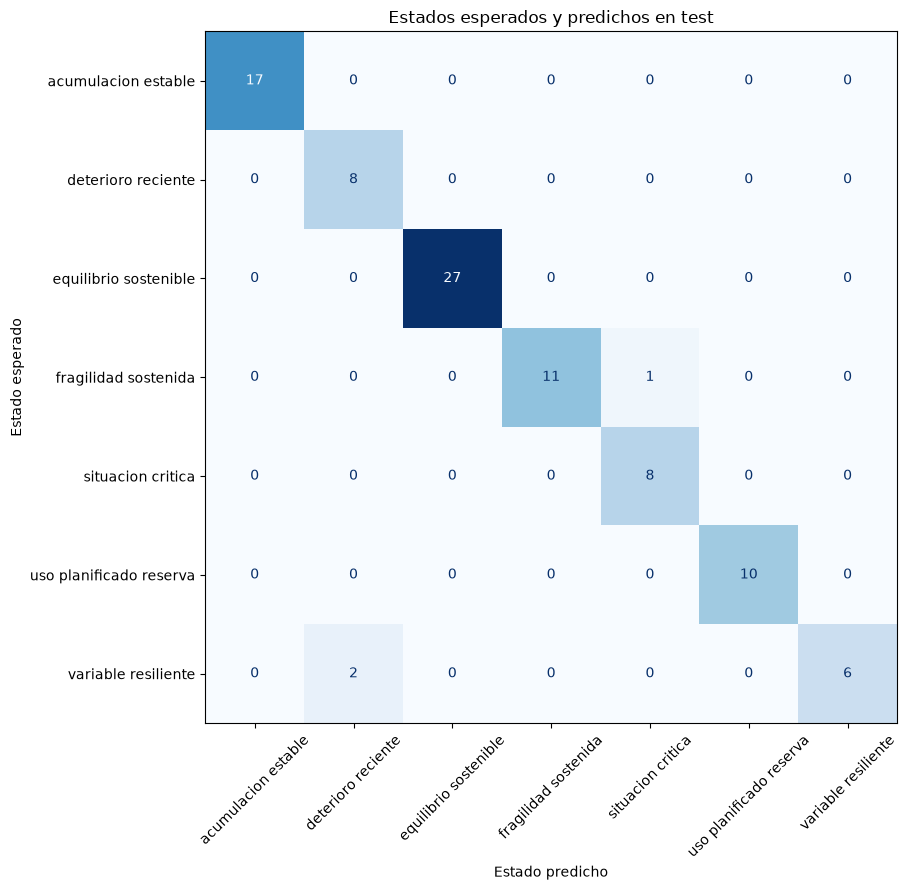

In [14]:
#Mostrar matriz de confusión
etiquetas_estados = sorted(y.unique())
figura, eje = plt.subplots(figsize=(11, 9))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    prediccion_test,
    labels=etiquetas_estados,
    display_labels=[estado.replace('_', ' ') for estado in etiquetas_estados],
    cmap='Blues',
    colorbar=False,
    xticks_rotation=45,
    ax=eje,
)

eje.set_title('Estados esperados y predichos en test')
eje.set_xlabel('Estado predicho')
eje.set_ylabel('Estado esperado')
figura.tight_layout()

ruta_graficas.mkdir(parents=True, exist_ok=True)
figura.savefig(ruta_graficas / '04_matriz_confusion_estados.png', dpi=180, bbox_inches='tight')
plt.show()

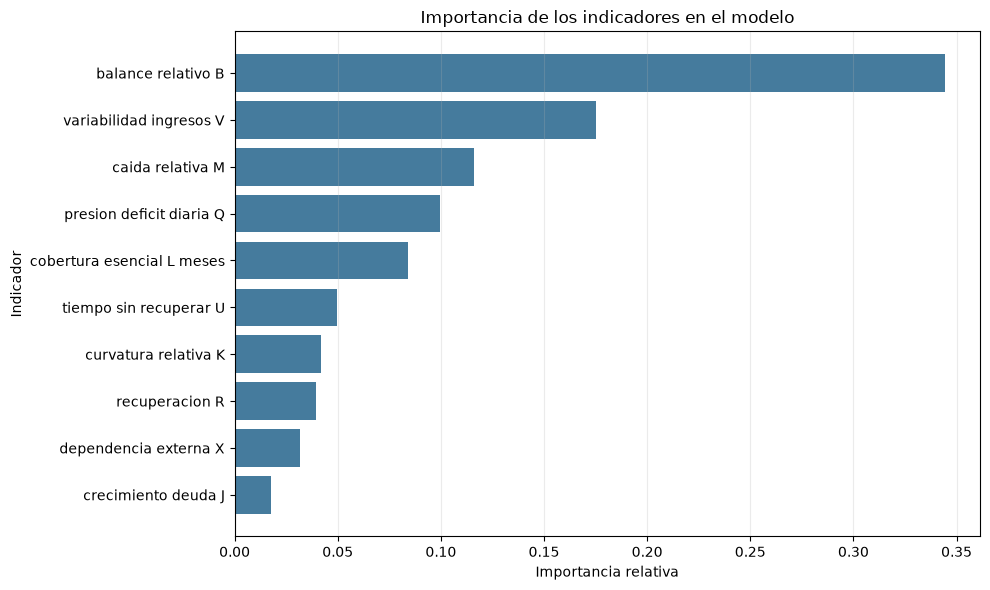

,indicador,importancia
0,balance_relativo_B,0.344149
6,variabilidad_ingresos_V,0.175084
2,caida_relativa_M,0.116234
1,presion_deficit_diaria_Q,0.099565
7,cobertura_esencial_L_meses,0.084186
3,tiempo_sin_recuperar_U,0.049825
5,curvatura_relativa_K,0.042074
4,recuperacion_R,0.039622
8,dependencia_externa_X,0.031642
9,crecimiento_deuda_J,0.017619


In [15]:
#Mostrar importancia
estimador_final = modelo_final.named_steps['modelo']

if hasattr(estimador_final, 'feature_importances_'):
    importancia_valores = estimador_final.feature_importances_
else:
    importancia_valores = np.abs(estimador_final.coef_).mean(axis=0)

importancia_indicadores = pd.DataFrame({
    'indicador': variables_modelo,
    'importancia': importancia_valores,
}).sort_values('importancia', ascending=True)

figura, eje = plt.subplots(figsize=(10, 6))
eje.barh(
    [indicador.replace('_', ' ') for indicador in importancia_indicadores['indicador']],
    importancia_indicadores['importancia'],
    color='#457B9D',
)

eje.set_title('Importancia de los indicadores en el modelo')
eje.set_xlabel('Importancia relativa')
eje.set_ylabel('Indicador')
eje.grid(axis='x', alpha=0.25)
figura.tight_layout()
figura.savefig(ruta_graficas / '04_importancia_indicadores.png', dpi=180, bbox_inches='tight')
plt.show()

display(importancia_indicadores.sort_values('importancia', ascending=False))

## 9. Inferencia con evidencia y porcentajes

In [16]:
#Definir inferencia
campos_evidencia = [
    'dias_observados',
    'transacciones_observadas',
    'porcentaje_transacciones_clasificables',
    *indicadores_crudos,
]


def revisar_evidencia(entrada):
    faltantes = [
        campo
        for campo in campos_evidencia
        if campo not in entrada or pd.isna(entrada[campo])
    ]
    motivos = []

    if faltantes:
        motivos.append('indicadores_faltantes:' + '|'.join(faltantes))
    if not faltantes:
        if float(entrada['dias_observados']) < MIN_DIAS_TRAYECTORIA:
            motivos.append('historia_menor_a_30_dias')
        if float(entrada['transacciones_observadas']) < MIN_TRANSACCIONES_TRAYECTORIA:
            motivos.append('menos_de_10_transacciones')
        if float(entrada['porcentaje_transacciones_clasificables']) < MIN_PCT_CLASIFICABLE:
            motivos.append('cobertura_de_clasificacion_insuficiente')
        if float(entrada['actividad_A']) <= 0:
            motivos.append('actividad_financiera_no_calculable')

    return motivos


def clasificar_trayectoria(entrada):
    motivos = revisar_evidencia(entrada)

    if motivos:
        return {
            'estado_calculo': 'evidencia_insuficiente',
            'estado_trayectoria': 'no_disponible',
            'confianza_pct': np.nan,
            'nivel_incertidumbre': 'alta',
            'motivos': motivos,
            'porcentajes_estado': {},
        }

    vector = preparar_indicadores(pd.DataFrame([entrada]))
    probabilidades = modelo_final.predict_proba(vector)[0]
    posicion = int(np.argmax(probabilidades))
    confianza = float(probabilidades[posicion])
    estado_probable = modelo_final.classes_[posicion]
    porcentajes = {
        estado: round(float(probabilidad) * 100, 2)
        for estado, probabilidad in sorted(
            zip(modelo_final.classes_, probabilidades),
            key=lambda elemento: elemento[1],
            reverse=True,
        )
    }

    if confianza < UMBRAL_CONFIANZA:
        estado_salida = 'estado_incierto'
        estado_calculo = 'requiere_confirmacion'
        incertidumbre = 'alta'
    else:
        estado_salida = estado_probable
        estado_calculo = 'calculado'
        incertidumbre = 'baja' if confianza >= UMBRAL_CONFIANZA_ALTA else 'media'

    indicadores = vector.iloc[0].round(4).to_dict()

    return {
        'estado_calculo': estado_calculo,
        'estado_trayectoria': estado_salida,
        'estado_mas_probable': estado_probable,
        'confianza_pct': round(confianza * 100, 2),
        'nivel_incertidumbre': incertidumbre,
        'motivos': [],
        'indicadores_normalizados': indicadores,
        'porcentajes_estado': porcentajes,
    }

In [17]:
#Clasificar ventanas
resultados_modelo = []

for indice, fila in trayectorias.iterrows():
    resultado = clasificar_trayectoria(fila.to_dict())
    registro = {
        'ventana_id': fila['ventana_id'],
        'perfil_id': fila['perfil_id'],
        'fecha_corte': fila['fecha_corte'],
        'periodo_desde': fila['periodo_desde'],
        'periodo_hasta': fila['periodo_hasta'],
        'estado_esperado': fila['estado_trayectoria'],
        'estado_modelo': resultado['estado_trayectoria'],
        'estado_calculo_modelo': resultado['estado_calculo'],
        'confianza_pct': resultado['confianza_pct'],
        'nivel_incertidumbre_modelo': resultado['nivel_incertidumbre'],
        'particion': fila['particion'],
    }

    for estado, porcentaje in resultado['porcentajes_estado'].items():
        registro[f'prob_{estado}_pct'] = porcentaje

    resultados_modelo.append(registro)

resultados_modelo = pd.DataFrame(resultados_modelo)
resumen_confianza = resultados_modelo.groupby(
    ['particion', 'estado_calculo_modelo']
).size().rename('ventanas').reset_index()

display(resumen_confianza)
display(resultados_modelo.head(5))

,particion,estado_calculo_modelo,ventanas
0,test,calculado,88
1,test,requiere_confirmacion,2
2,train,calculado,420
3,validation,calculado,90


,ventana_id,perfil_id,fecha_corte,periodo_desde,periodo_hasta,estado_esperado,estado_modelo,estado_calculo_modelo,confianza_pct,nivel_incertidumbre_modelo,particion,prob_acumulacion_estable_pct,prob_equilibrio_sostenible_pct,prob_variable_resiliente_pct,prob_deterioro_reciente_pct,prob_fragilidad_sostenida_pct,prob_situacion_critica_pct,prob_uso_planificado_reserva_pct
0,VEN_0001_1,PERF_0001,2026-04-30,2026-04-01,2026-04-30,acumulacion_estable,acumulacion_estable,calculado,91.81,baja,train,91.81,7.45,0.65,0.09,0.0,0.0,0.0
1,VEN_0001_2,PERF_0001,2026-05-31,2026-04-01,2026-05-31,acumulacion_estable,acumulacion_estable,calculado,95.31,baja,train,95.31,4.32,0.37,0.00,0.0,0.0,0.0
2,VEN_0001_3,PERF_0001,2026-06-30,2026-04-01,2026-06-30,acumulacion_estable,acumulacion_estable,calculado,98.36,baja,train,98.36,1.07,0.56,0.00,0.0,0.0,0.0
3,VEN_0002_1,PERF_0002,2026-04-30,2026-04-01,2026-04-30,equilibrio_sostenible,equilibrio_sostenible,calculado,97.50,baja,train,2.50,97.50,0.00,0.00,0.0,0.0,0.0
4,VEN_0002_2,PERF_0002,2026-05-31,2026-04-01,2026-05-31,equilibrio_sostenible,equilibrio_sostenible,calculado,95.70,baja,train,3.95,95.70,0.24,0.11,0.0,0.0,0.0


In [18]:
#Integrar patrones finales
ultimas_ventanas = resultados_modelo.sort_values('fecha_corte').groupby('perfil_id').tail(1).copy()
regularidades_perfil = recurrencias.loc[
    recurrencias['estado_patron'].eq('regularidad_observada')
].groupby('perfil_id').size().rename('regularidades_observadas').reset_index()

eventos_perfil = eventos_inusuales.groupby('perfil_id').size().rename('eventos_inusuales_observados').reset_index()
tendencias_perfil = tendencias_temporales.pivot_table(
    index='perfil_id',
    columns='direccion',
    values='estado_tendencia',
    aggfunc='first',
).rename(columns={
    'entrada': 'tendencia_entradas',
    'salida': 'tendencia_salidas',
}).reset_index()

estado_actual_perfiles = ultimas_ventanas.merge(
    regularidades_perfil,
    on='perfil_id',
    how='left',
).merge(
    eventos_perfil,
    on='perfil_id',
    how='left',
).merge(
    tendencias_perfil,
    on='perfil_id',
    how='left',
)

display(estado_actual_perfiles.head(10))

,ventana_id,perfil_id,fecha_corte,periodo_desde,periodo_hasta,estado_esperado,estado_modelo,estado_calculo_modelo,confianza_pct,nivel_incertidumbre_modelo,...,prob_equilibrio_sostenible_pct,prob_variable_resiliente_pct,prob_deterioro_reciente_pct,prob_fragilidad_sostenida_pct,prob_situacion_critica_pct,prob_uso_planificado_reserva_pct,regularidades_observadas,eventos_inusuales_observados,tendencia_entradas,tendencia_salidas
0,VEN_0164_3,PERF_0164,2026-06-30,2026-04-01,2026-06-30,variable_resiliente,variable_resiliente,calculado,64.19,media,...,0.18,64.19,27.76,3.44,0.00,4.42,2,4.0,estabilidad_observada,estabilidad_observada
1,VEN_0172_3,PERF_0172,2026-06-30,2026-04-01,2026-06-30,uso_planificado_reserva,uso_planificado_reserva,calculado,87.05,baja,...,0.24,12.13,0.22,0.30,0.00,87.05,2,4.0,disminucion_observada,aumento_observado
2,VEN_0167_3,PERF_0167,2026-06-30,2026-04-01,2026-06-30,fragilidad_sostenida,fragilidad_sostenida,calculado,96.79,baja,...,0.00,0.26,2.10,96.79,0.00,0.86,3,2.0,disminucion_observada,estabilidad_observada
3,VEN_0196_3,PERF_0196,2026-06-30,2026-04-01,2026-06-30,situacion_critica,situacion_critica,calculado,100.00,baja,...,0.00,0.00,0.00,0.00,100.00,0.00,3,NaN,disminucion_observada,estabilidad_observada
4,VEN_0184_3,PERF_0184,2026-06-30,2026-04-01,2026-06-30,equilibrio_sostenible,equilibrio_sostenible,calculado,93.40,baja,...,93.40,1.44,3.74,0.18,0.00,0.08,2,4.0,estabilidad_observada,disminucion_observada
5,VEN_0160_3,PERF_0160,2026-06-30,2026-04-01,2026-06-30,fragilidad_sostenida,fragilidad_sostenida,calculado,99.85,baja,...,0.00,0.00,0.00,99.85,0.15,0.00,2,2.0,disminucion_observada,aumento_observado
6,VEN_0189_3,PERF_0189,2026-06-30,2026-04-01,2026-06-30,situacion_critica,situacion_critica,calculado,100.00,baja,...,0.00,0.00,0.00,0.00,100.00,0.00,2,2.0,estabilidad_observada,estabilidad_observada
7,VEN_0152_3,PERF_0152,2026-06-30,2026-04-01,2026-06-30,deterioro_reciente,deterioro_reciente,calculado,76.12,baja,...,1.22,21.11,76.12,0.00,0.00,1.55,2,6.0,aumento_observado,estabilidad_observada
8,VEN_0162_3,PERF_0162,2026-06-30,2026-04-01,2026-06-30,acumulacion_estable,acumulacion_estable,calculado,98.85,baja,...,0.66,0.49,0.00,0.00,0.00,0.00,1,2.0,estabilidad_observada,estabilidad_observada
9,VEN_0197_3,PERF_0197,2026-06-30,2026-04-01,2026-06-30,acumulacion_estable,acumulacion_estable,calculado,96.71,baja,...,0.80,2.49,0.00,0.00,0.00,0.00,1,2.0,estabilidad_observada,disminucion_observada


## 10. Gráficas de trayectoria

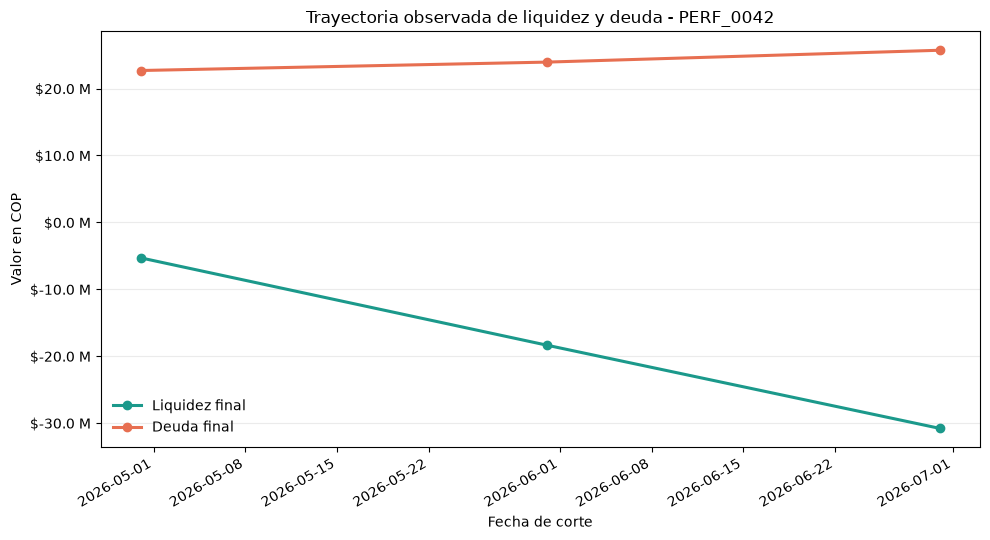

In [19]:
#Graficar trayectoria individual
perfil_grafica = PERFIL_GRAFICA if PERFIL_GRAFICA in trayectorias['perfil_id'].values else trayectorias['perfil_id'].iloc[0]
trayectoria_grafica = trayectorias.loc[
    trayectorias['perfil_id'].eq(perfil_grafica)
].sort_values('fecha_corte')

figura, eje = plt.subplots(figsize=(10, 5.5))
eje.plot(
    trayectoria_grafica['fecha_corte'],
    trayectoria_grafica['liquidez_final'],
    marker='o',
    linewidth=2.2,
    color='#1B998B',
    label='Liquidez final',
)
eje.plot(
    trayectoria_grafica['fecha_corte'],
    trayectoria_grafica['deuda_final'],
    marker='o',
    linewidth=2.2,
    color='#E76F51',
    label='Deuda final',
)

eje.set_title(f'Trayectoria observada de liquidez y deuda - {perfil_grafica}')
eje.set_xlabel('Fecha de corte')
eje.set_ylabel('Valor en COP')
eje.yaxis.set_major_formatter(FuncFormatter(lambda valor, posicion: f'${valor / 1_000_000:.1f} M'))
eje.legend(frameon=False)
eje.grid(axis='y', alpha=0.25)
figura.autofmt_xdate()
figura.tight_layout()
figura.savefig(ruta_graficas / '04_trayectoria_liquidez_deuda.png', dpi=180, bbox_inches='tight')
plt.show()

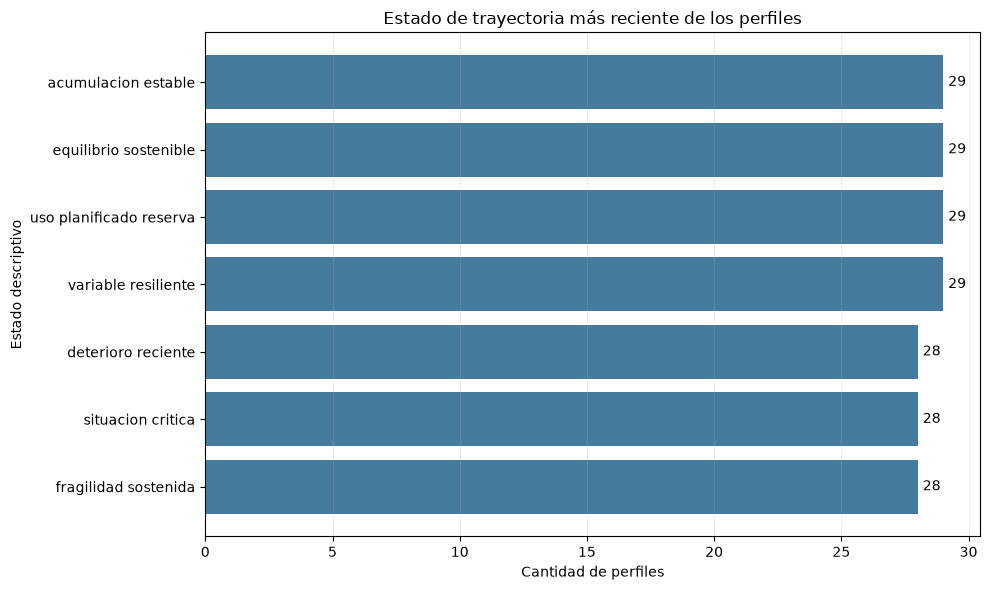

In [20]:
#Graficar estados actuales
distribucion_estados = estado_actual_perfiles['estado_modelo'].value_counts().sort_values()

figura, eje = plt.subplots(figsize=(10, 6))
eje.barh(
    [estado.replace('_', ' ') for estado in distribucion_estados.index],
    distribucion_estados.values,
    color='#457B9D',
)
eje.set_title('Estado de trayectoria más reciente de los perfiles')
eje.set_xlabel('Cantidad de perfiles')
eje.set_ylabel('Estado descriptivo')
eje.grid(axis='x', alpha=0.25)

for posicion, valor in enumerate(distribucion_estados.values):
    eje.text(valor + 0.2, posicion, str(int(valor)), va='center')

figura.tight_layout()
figura.savefig(ruta_graficas / '04_distribucion_estados_actuales.png', dpi=180, bbox_inches='tight')
plt.show()

## 11. Serialización y exportación

In [21]:
#Guardar artefactos
ruta_modelo.parent.mkdir(parents=True, exist_ok=True)
ruta_resultados.mkdir(parents=True, exist_ok=True)

artefacto = {
    'version_modelo': VERSION_MODELO,
    'modelo': modelo_final,
    'modelo_seleccionado': nombre_modelo_final,
    'variables_modelo': variables_modelo,
    'indicadores_crudos': indicadores_crudos,
    'umbral_confianza': UMBRAL_CONFIANZA,
    'umbral_confianza_alta': UMBRAL_CONFIANZA_ALTA,
    'min_dias_trayectoria': MIN_DIAS_TRAYECTORIA,
    'min_transacciones_trayectoria': MIN_TRANSACCIONES_TRAYECTORIA,
    'min_pct_clasificable': MIN_PCT_CLASIFICABLE,
    'factor_capital_pago': float(factor_capital_pago),
    'clases': list(modelo_final.classes_),
    'metricas_validation': metricas_validation.to_dict(orient='records'),
    'metricas_test': metricas_test.to_dict(orient='records'),
    'ficha_indicadores': ficha_indicadores.to_dict(orient='records'),
    'principio_etico': 'el estado describe una ventana y no la identidad de la persona',
}

joblib.dump(artefacto, ruta_modelo)

ruta_ventanas = ruta_resultados / '04_estados_por_ventana.csv'
ruta_estados_actuales = ruta_resultados / '04_estados_trayectoria.csv'
ruta_metricas = ruta_resultados / '04_metricas_modelo.csv'

resultados_modelo.to_csv(ruta_ventanas, index=False)
estado_actual_perfiles.to_csv(ruta_estados_actuales, index=False)
pd.concat([
    metricas_validation.assign(particion='validation'),
    metricas_test.assign(particion='test'),
], ignore_index=True).to_csv(ruta_metricas, index=False)

archivos_generados = pd.DataFrame([
    {'artefacto': 'modelo', 'ruta': str(ruta_modelo), 'filas': np.nan},
    {'artefacto': 'estados por ventana', 'ruta': str(ruta_ventanas), 'filas': len(resultados_modelo)},
    {'artefacto': 'estados actuales', 'ruta': str(ruta_estados_actuales), 'filas': len(estado_actual_perfiles)},
    {'artefacto': 'métricas', 'ruta': str(ruta_metricas), 'filas': len(metricas_validation) + len(metricas_test)},
])

display(archivos_generados)

,artefacto,ruta,filas
0,modelo,../Modelos/04_estados_trayectoria.joblib,NaN
1,estados por ventana,../Resultados/04_estados_por_ventana.csv,600.0
2,estados actuales,../Resultados/04_estados_trayectoria.csv,200.0
3,métricas,../Resultados/04_metricas_modelo.csv,3.0


## 12. Pruebas manuales

In [22]:
#Probar trayectoria estable
test_trayectoria_estable = {
    'dias_observados': 30,
    'transacciones_observadas': 31,
    'porcentaje_transacciones_clasificables': 0.9677,
    'actividad_A': 15451000,
    'balance_operativo_B': 4009000,
    'presion_deficit_Q': 0.0,
    'caida_maxima_M': 2707000,
    'tiempo_sin_recuperar_U_dias': 1,
    'recuperacion_R': 0.5,
    'curvatura_K': 531261.9048,
    'variabilidad_ingresos_V': 0.0,
    'cobertura_esencial_L_meses': 12.5937,
    'dependencia_externa_X': 0.0,
    'crecimiento_deuda_J': 0.0,
}

resultado_estable = clasificar_trayectoria(test_trayectoria_estable)
display(pd.DataFrame([{
    'caso': 'trayectoria_estable',
    'estado': resultado_estable['estado_trayectoria'],
    'confianza_pct': resultado_estable['confianza_pct'],
    'incertidumbre': resultado_estable['nivel_incertidumbre'],
}]))

display(pd.DataFrame([resultado_estable['porcentajes_estado']]))
assert resultado_estable['estado_trayectoria'] == 'acumulacion_estable'

,caso,estado,confianza_pct,incertidumbre
0,trayectoria_estable,acumulacion_estable,98.16,baja


,acumulacion_estable,equilibrio_sostenible,variable_resiliente,deterioro_reciente,fragilidad_sostenida,situacion_critica,uso_planificado_reserva
0,98.16,1.64,0.2,0.0,0.0,0.0,0.0


In [23]:
#Probar presión sostenida
test_presion_sostenida = {
    'dias_observados': 61,
    'transacciones_observadas': 67,
    'porcentaje_transacciones_clasificables': 0.9701,
    'actividad_A': 35187000,
    'balance_operativo_B': -12363000,
    'presion_deficit_Q': 26.582,
    'caida_maxima_M': 11746000,
    'tiempo_sin_recuperar_U_dias': 60,
    'recuperacion_R': 0.0,
    'curvatura_K': -152733.3333,
    'variabilidad_ingresos_V': 0.1031,
    'cobertura_esencial_L_meses': 0.0,
    'dependencia_externa_X': 0.0736,
    'crecimiento_deuda_J': -0.0426,
}

resultado_presion = clasificar_trayectoria(test_presion_sostenida)
display(pd.DataFrame([{
    'caso': 'presion_sostenida',
    'estado': resultado_presion['estado_trayectoria'],
    'confianza_pct': resultado_presion['confianza_pct'],
    'incertidumbre': resultado_presion['nivel_incertidumbre'],
}]))

display(pd.DataFrame([resultado_presion['porcentajes_estado']]))
assert resultado_presion['estado_trayectoria'] == 'fragilidad_sostenida'

,caso,estado,confianza_pct,incertidumbre
0,presion_sostenida,fragilidad_sostenida,90.7,baja


,fragilidad_sostenida,deterioro_reciente,variable_resiliente,uso_planificado_reserva,situacion_critica,equilibrio_sostenible,acumulacion_estable
0,90.7,6.64,1.26,0.97,0.32,0.11,0.0


In [24]:
#Probar evidencia insuficiente
test_historia_insuficiente = {
    'dias_observados': 1,
    'transacciones_observadas': 1,
    'porcentaje_transacciones_clasificables': 1.0,
    'actividad_A': 120000,
    'balance_operativo_B': -120000,
    'presion_deficit_Q': np.nan,
    'caida_maxima_M': np.nan,
    'tiempo_sin_recuperar_U_dias': np.nan,
    'recuperacion_R': np.nan,
    'curvatura_K': np.nan,
    'variabilidad_ingresos_V': np.nan,
    'cobertura_esencial_L_meses': np.nan,
    'dependencia_externa_X': np.nan,
    'crecimiento_deuda_J': np.nan,
}

resultado_insuficiente = clasificar_trayectoria(test_historia_insuficiente)
display(pd.DataFrame([{
    'caso': 'una_sola_transaccion',
    'estado_calculo': resultado_insuficiente['estado_calculo'],
    'estado': resultado_insuficiente['estado_trayectoria'],
    'motivos': resultado_insuficiente['motivos'],
    'porcentajes_estado': resultado_insuficiente['porcentajes_estado'],
}]))

assert resultado_insuficiente['estado_calculo'] == 'evidencia_insuficiente'
assert resultado_insuficiente['porcentajes_estado'] == {}

,caso,estado_calculo,estado,motivos,porcentajes_estado
0,una_sola_transaccion,evidencia_insuficiente,no_disponible,[indicadores_faltantes:presion_deficit_Q|caida...,{}
